# Task 2

---

## Predictive modeling of customer bookings

This Jupyter notebook includes some code to get you started with this predictive modeling task. We will use various packages for data manipulation, feature engineering and machine learning.

### Exploratory data analysis

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

In [96]:
import pandas as pd

In [98]:
df = pd.read_csv(r"C:\Users\meets\Downloads/customer_booking.csv", encoding="ISO-8859-1")
df.head()


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


The `.head()` method allows us to view the first 5 rows in the dataset, this is useful for visual inspection of our columns

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

Before we compute any statistics on the data, lets do any necessary data conversion

In [104]:
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [106]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)

In [108]:
df["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5], dtype=int64)

In [110]:
df.describe(include="object")

,sales_channel,trip_type,route,booking_origin
count,50000,50000,50000,50000
unique,2,3,799,104
top,Internet,RoundTrip,AKLKUL,Australia
freq,44382,49497,2680,17872


In [112]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.

From this point, you should continue exploring the dataset with some visualisations and other metrics that you think may be useful. Then, you should prepare your dataset for predictive modelling. Finally, you should train your machine learning model, evaluate it with performance metrics and output visualisations for the contributing variables. All of this analysis should be summarised in your single slide.

In [115]:
df.select_dtypes(include="object").apply(pd.unique)

sales_channel                                    [Internet, Mobile]
trip_type                           [RoundTrip, CircleTrip, OneWay]
route             [AKLDEL, AKLHGH, AKLHND, AKLICN, AKLKIX, AKLKT...
booking_origin    [New Zealand, India, United Kingdom, China, So...
dtype: object

In [117]:
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score

# For gradient boosting
from sklearn.metrics import make_scorer, f1_score
from sklearn.ensemble import HistGradientBoostingClassifier
import numpy as np




In [119]:
# Define target and features
target= "booking_complete"
X= df.drop(columns=[target])
Y= df[target]

In [121]:
# Identify Column types
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns


In [123]:
# Preprocessing   [Common for both random forest and gradient boosting]
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore",sparse_output=False), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)


In [125]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import joblib

# ---------------------------------------------------
# 1️⃣ TRAIN / TEST SPLIT (FIRST STEP — VERY IMPORTANT)
# ---------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

# ---------------------------------------------------
# 2️⃣ DEFINE MODEL + PIPELINE
# ---------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    class_weight="balanced",
    n_jobs=1
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf)
    ]
)

# ---------------------------------------------------
# 3️⃣ HYPERPARAMETER SEARCH (TRAIN ONLY)
# ---------------------------------------------------
param_dist = {
    "model__max_depth": [8, 12, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [2, 5],
    "model__max_features": ["sqrt", "log2"]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=8,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

best_pipe = search.best_estimator_

print("\nBest Parameters:")
print(search.best_params_)

print("\nBest Train CV ROC-AUC:")
print(search.best_score_)

# ---------------------------------------------------
# 4️⃣ OOF PREDICTIONS ON TRAIN (FOR THRESHOLD TUNING)
# ---------------------------------------------------
oof_proba_train = cross_val_predict(
    best_pipe,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

# ---------------------------------------------------
# 5️⃣ THRESHOLD SWEEP (TRAIN ONLY)
# ---------------------------------------------------
thresholds = np.linspace(0.3, 0.7, 21)

target_prec_min = 0.30     # your minimum precision requirement
target_rec_min = 0.70      # your recall requirement

best_thr = None
best_f1 = -1

for thr in thresholds:
    y_pred = (oof_proba_train >= thr).astype(int)
    prec = precision_score(y_train, y_pred, zero_division=0)
    rec = recall_score(y_train, y_pred, zero_division=0)
    f1 = f1_score(y_train, y_pred, zero_division=0)

    if (prec >= target_prec_min) and (rec >= target_rec_min):
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr

if best_thr is None:
    best_thr = 0.5  # fallback
    print("\nNo threshold satisfied constraints. Using default 0.5")
else:
    print(f"\nChosen Threshold (from TRAIN only): {best_thr:.2f}")
    print(f"Best TRAIN F1 at that threshold: {best_f1:.4f}")

# ---------------------------------------------------
# 6️⃣ FINAL EVALUATION ON TEST (NEVER TOUCHED BEFORE)
# ---------------------------------------------------
best_pipe.fit(X_train, y_train)

test_proba = best_pipe.predict_proba(X_test)[:, 1]
y_test_pred = (test_proba >= best_thr).astype(int)

print("\nTEST METRICS:")
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1       :", f1_score(y_test, y_test_pred))
print("ROC-AUC  :", roc_auc_score(y_test, test_proba))

# ---------------------------------------------------
# 7️⃣ OPTIONAL: TRAIN FINAL MODEL ON ALL DATA FOR DEPLOYMENT
# ---------------------------------------------------
best_pipe.fit(X, Y)
joblib.dump(best_pipe, "booking_completion_pipeline.joblib")

print("\nFinal model saved as booking_completion_pipeline.joblib")

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best Parameters:
{'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None}

Best Train CV ROC-AUC:
0.7820012932421259

Chosen Threshold (from TRAIN only): 0.48
Best TRAIN F1 at that threshold: 0.4324

TEST METRICS:
Precision: 0.3152050113895216
Recall   : 0.7399732620320856
F1       : 0.4420926517571885
ROC-AUC  : 0.7927329180731559

Final model saved as booking_completion_pipeline.joblib


In [126]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# ---------------------------------------------------
# Thresholds to try
# ---------------------------------------------------
thresholds = np.linspace(0.3, 0.7, 21)

# Business constraint bands
target_prec_min, target_prec_max = 0.45, 0.55
target_rec_min, target_rec_max = 0.72, 0.85

best_thr = None
best_f1 = -1
best_prec = None
best_rec = None

candidates = []

# ---------------------------------------------------
# Sweep thresholds using TRAIN OOF predictions
# ---------------------------------------------------
for thr in thresholds:
    y_pred = (oof_proba_train >= thr).astype(int)

    prec = precision_score(y_train, y_pred, zero_division=0)
    rec = recall_score(y_train, y_pred, zero_division=0)
    f1 = f1_score(y_train, y_pred, zero_division=0)

    # store everything for inspection
    candidates.append((thr, prec, rec, f1))

    # keep thresholds satisfying business constraints
    if (target_prec_min <= prec <= target_prec_max) and \
       (target_rec_min <= rec <= target_rec_max):

        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
            best_prec = prec
            best_rec = rec

# ---------------------------------------------------
# Print all candidates
# ---------------------------------------------------
print("\nAll tried thresholds (TRAIN OOF):")
for thr, prec, rec, f1 in candidates:
    print(f"{thr:.2f}  P={prec:.3f}  R={rec:.3f}  F1={f1:.3f}")

# ---------------------------------------------------
# Final selection
# ---------------------------------------------------
if best_thr is None:
    print("\nNo threshold satisfied requested precision/recall ranges.")
    best_thr = 0.5  # fallback
else:
    print(f"\nChosen threshold (TRAIN only): {best_thr:.2f}")
    print(f"Precision: {best_prec:.3f}")
    print(f"Recall   : {best_rec:.3f}")
    print(f"F1       : {best_f1:.3f}") 


All tried thresholds (TRAIN OOF):
0.30  P=0.234  R=0.895  F1=0.371
0.32  P=0.243  R=0.884  F1=0.381
0.34  P=0.251  R=0.870  F1=0.389
0.36  P=0.259  R=0.857  F1=0.397
0.38  P=0.267  R=0.841  F1=0.405
0.40  P=0.276  R=0.825  F1=0.413
0.42  P=0.284  R=0.805  F1=0.420
0.44  P=0.293  R=0.781  F1=0.426
0.46  P=0.302  R=0.752  F1=0.431
0.48  P=0.310  R=0.715  F1=0.432
0.50  P=0.320  R=0.678  F1=0.435
0.52  P=0.331  R=0.638  F1=0.436
0.54  P=0.344  R=0.595  F1=0.436
0.56  P=0.356  R=0.548  F1=0.431
0.58  P=0.365  R=0.496  F1=0.421
0.60  P=0.377  R=0.443  F1=0.407
0.62  P=0.386  R=0.385  F1=0.385
0.64  P=0.399  R=0.326  F1=0.359
0.66  P=0.414  R=0.260  F1=0.319
0.68  P=0.436  R=0.203  F1=0.277
0.70  P=0.463  R=0.157  F1=0.235

No threshold satisfied requested precision/recall ranges.



=== Top 20 Transformed Features ===
                        feature  importance
  cat__booking_origin_Australia      0.1327
   cat__booking_origin_Malaysia      0.0857
            num__length_of_stay      0.0842
             num__purchase_lead      0.0687
               num__flight_hour      0.0506
           num__flight_duration      0.0484
                num__flight_day      0.0365
       num__wants_extra_baggage      0.0228
            num__num_passengers      0.0210
      num__wants_preferred_seat      0.0157
cat__booking_origin_South Korea      0.0156
     num__wants_in_flight_meals      0.0139
  cat__booking_origin_Indonesia      0.0130
              cat__route_PENTPE      0.0127
     cat__booking_origin_Taiwan      0.0103
      cat__booking_origin_Japan      0.0092
      cat__sales_channel_Mobile      0.0091
  cat__booking_origin_Singapore      0.0091
    cat__sales_channel_Internet      0.0091
              cat__route_ICNSYD      0.0090

=== Importance Aggregated by ORIGINAL 

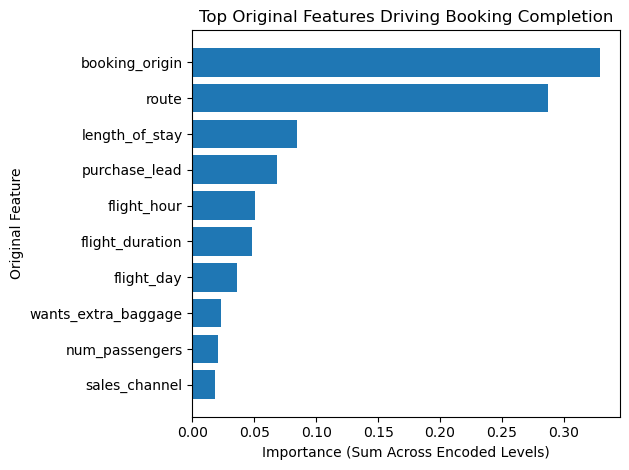

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1️⃣ Extract model + preprocessor
# ---------------------------------------------------
model = best_pipe.named_steps["model"]
preprocessor = best_pipe.named_steps["preprocessor"]

# ---------------------------------------------------
# 2️⃣ Get transformed feature names
# ---------------------------------------------------
feature_names = preprocessor.get_feature_names_out()
importances = model.feature_importances_

feat_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feat_importance_df = feat_importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n=== Top 20 Transformed Features ===")
print(feat_importance_df.head(20).to_string(index=False, float_format="%.4f"))

# ---------------------------------------------------
# 3️⃣ Aggregate back to ORIGINAL columns
# ---------------------------------------------------
original_cols = X.columns.tolist()

def map_to_original(col_name):
    for orig in original_cols:
        if orig in col_name:
            return orig
    return "OTHER"

feat_importance_df["original_feature"] = \
    feat_importance_df["feature"].apply(map_to_original)

agg_importance = (
    feat_importance_df
    .groupby("original_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

print("\n=== Importance Aggregated by ORIGINAL Columns ===")
print(agg_importance.to_string(index=False, float_format="%.4f"))

# ---------------------------------------------------
# 4️⃣ Plot Aggregated Importance (Top 10)
# ---------------------------------------------------
top_k = 10
top_original = agg_importance.head(top_k)

plt.figure()
plt.barh(
    top_original["original_feature"][::-1],
    top_original["importance"][::-1]
)
plt.xlabel("Importance (Sum Across Encoded Levels)")
plt.ylabel("Original Feature")
plt.title("Top Original Features Driving Booking Completion")
plt.tight_layout()
plt.show()